ex_LP_exercise

In [1]:
import pyomo.environ as pyo
import numpy as np
import time
from pyomo.environ import *
from pyomo.opt import SolverFactory


model = pyo.ConcreteModel()

model.x = pyo.Var(bounds=(-np.inf,3))
model.y = pyo.Var(bounds=(0,np.inf))

x = model.x
y = model.y

model.C1 = pyo.Constraint(expr= x+y<=8)
model.C2 = pyo.Constraint(expr= 8*x+3*y>=-24)
model.C3 = pyo.Constraint(expr= -6*x+8*y<=48)
model.C4 = pyo.Constraint(expr= 3*x+5*y<=15)

model.obj = pyo.Objective(expr= -4*x-2*y, sense=minimize)

tempo_inicial = time.time()
opt = SolverFactory('gurobi')
opt.solve(model)
tempo = time.time()-tempo_inicial

x_value = pyo.value(x)
y_value = pyo.value(y)

print('tempo:',tempo)
print('x:',x_value)
print('y:',y_value)

tempo: 0.07622528076171875
x: 3.0
y: 1.2


ex_LP_ortools

In [2]:
from ortools.linear_solver import pywraplp

solver = pywraplp.Solver.CreateSolver('GLOP')

x = solver.NumVar(0,10,'x')
y = solver.NumVar(0,10,'y')

solver.Add(-x+2*y<=8)
solver.Add(2*x+y<=14)
solver.Add(2*x-y<=10)

solver.Maximize(x+y)

results = solver.Solve()

if results==pywraplp.Solver.OPTIMAL: print('Optimal Found')

print('x:', x.solution_value())
print('y:', y.solution_value())

Optimal Found
x: 4.0
y: 6.0


ex_LP_pulp

In [3]:
import pulp as pl

model = pl.LpProblem('Ex', pl.LpMaximize)

x = pl.LpVariable('x',0,10)
y = pl.LpVariable('y',0,10)

model += -x+2*y<=8
model += 2*x+y<=14
model += 2*x-y<=10

model += x+y

status = model.solve()

x_value = pl.value(x)
y_value = pl.value(y)

print('x=',x_value)
print('y=',y_value)

x= 4.0
y= 6.0


ex_LP_pyomo

In [4]:
import pyomo.environ as pyo
from pyomo.environ import *
from pyomo.opt import SolverFactory

model = pyo.ConcreteModel()

model.x = pyo.Var(bounds=(0,10))
model.y = pyo.Var(bounds=(0,10))
x = model.x
y = model.y

model.C1 = pyo.Constraint(expr= -x+2*y<=8)
model.C2 = pyo.Constraint(expr= 2*x+y<=14)
model.C3 = pyo.Constraint(expr= 2*x-y<=10)

model.obj = pyo.Objective(expr= x+y, sense=maximize)

opt = SolverFactory('gurobi')
opt.solve(model)

model.pprint()

x_value = pyo.value(x)
y_value = pyo.value(y)

print('\n---------------------------------------------------------------------')
print('x=',x_value)
print('y=',y_value)

2 Var Declarations
    x : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :   4.0 :    10 : False : False :  Reals
    y : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :   6.0 :    10 : False : False :  Reals

1 Objective Declarations
    obj : Size=1, Index=None, Active=True
        Key  : Active : Sense    : Expression
        None :   True : maximize : x + y

3 Constraint Declarations
    C1 : Size=1, Index=None, Active=True
        Key  : Lower : Body      : Upper : Active
        None :  -Inf : - x + 2*y :   8.0 :   True
    C2 : Size=1, Index=None, Active=True
        Key  : Lower : Body    : Upper : Active
        None :  -Inf : 2*x + y :  14.0 :   True
    C3 : Size=1, Index=None, Active=True
        Key  : Lower : Body    : Upper : Active
        None :  -Inf : 2*x - y :  10.0 :   True

6 Declarations: x y C1 C2 C3 obj

-----------------------------------------------

ex_LP_scip

In [5]:
from pyscipopt import Model

model = Model('exemplo')

x = model.addVar('x',lb=0,ub=10)
y = model.addVar('y',lb=0,ub=10)

model.setObjective(x+y, sense='maximize')

model.addCons(-x+2*y<=8)
model.addCons(2*x+y<=14)
model.addCons(2*x-y<=10)

model.optimize()

sol = model.getBestSol()

print('x=',sol[x])
print('y=',sol[y])

x= 4.0
y= 6.0


練習題 </br>
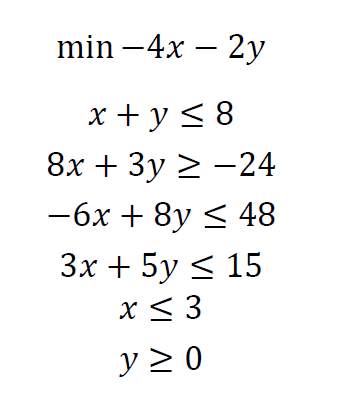

In [6]:
import pyomo.environ as pyo
import numpy as np
import time
from pyomo.environ import *
from pyomo.opt import SolverFactory


model = pyo.ConcreteModel()

model.x = pyo.Var(bounds=(-np.inf,3))
model.y = pyo.Var(bounds=(0,np.inf))

x = model.x
y = model.y

model.C1 = pyo.Constraint(expr= x+y<=8)
model.C2 = pyo.Constraint(expr= 8*x+3*y>=-24)
model.C3 = pyo.Constraint(expr= -6*x+8*y<=48)
model.C4 = pyo.Constraint(expr= 3*x+5*y<=15)

model.obj = pyo.Objective(expr= -4*x-2*y, sense=minimize)

tempo_inicial = time.time()
opt = SolverFactory('gurobi')
opt.solve(model)
tempo = time.time()-tempo_inicial

x_value = pyo.value(x)
y_value = pyo.value(y)

print('tempo:',tempo)
print('x:',x_value)
print('y:',y_value)

tempo: 0.013481378555297852
x: 3.0
y: 1.2


# cbc & ipopt

In [7]:
import pyomo.environ as pyo
from pyomo.environ import *
from pyomo.opt import SolverFactory

model = pyo.ConcreteModel()

model.x = pyo.Var(bounds=(0,10))
model.y = pyo.Var(bounds=(0,10))
x = model.x
y = model.y

model.C1 = pyo.Constraint(expr= -x+2*y<=8)
model.C2 = pyo.Constraint(expr= 2*x+y<=14)
model.C3 = pyo.Constraint(expr= 2*x-y<=10)

model.obj = pyo.Objective(expr= x+y, sense=maximize)

# cbc 只能線性
opt = SolverFactory('cbc', executable=r"solvers\cbc.exe")
# ipopt 可以非線性, ex: model.C1 = pyo.Constraint(expr= -x+2*y*x<=8)
# opt = SolverFactory('ipopt', executable=r"solvers\ipopt.exe")
opt.solve(model)

model.pprint()

x_value = pyo.value(x)
y_value = pyo.value(y)

print('\n---------------------------------------------------------------------')
print('x=',x_value)
print('y=',y_value)

2 Var Declarations
    x : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :   4.0 :    10 : False : False :  Reals
    y : Size=1, Index=None
        Key  : Lower : Value : Upper : Fixed : Stale : Domain
        None :     0 :   6.0 :    10 : False : False :  Reals

1 Objective Declarations
    obj : Size=1, Index=None, Active=True
        Key  : Active : Sense    : Expression
        None :   True : maximize : x + y

3 Constraint Declarations
    C1 : Size=1, Index=None, Active=True
        Key  : Lower : Body      : Upper : Active
        None :  -Inf : - x + 2*y :   8.0 :   True
    C2 : Size=1, Index=None, Active=True
        Key  : Lower : Body    : Upper : Active
        None :  -Inf : 2*x + y :  14.0 :   True
    C3 : Size=1, Index=None, Active=True
        Key  : Lower : Body    : Upper : Active
        None :  -Inf : 2*x - y :  10.0 :   True

6 Declarations: x y C1 C2 C3 obj

-----------------------------------------------

In [8]:
import pyomo.environ as pyo
from pyomo.environ import *
from pyomo.opt import SolverFactory

model = pyo.ConcreteModel()

model.x = pyo.Var(bounds=(0,10))
model.y = pyo.Var(bounds=(0,10))
x = model.x
y = model.y

model.C1 = pyo.Constraint(expr= -x+2*y<=8)
model.C2 = pyo.Constraint(expr= 2*x+y<=14)
model.C3 = pyo.Constraint(expr= 2*x-y<=10)

model.obj = pyo.Objective(expr= x+y, sense=maximize)

opt = SolverFactory('gurobi')
result = opt.solve(model)

# 若只要看 model.pprint()，可以改如下
model.x.pprint()

x_value = pyo.value(x)
y_value = pyo.value(y)

print(result)

x : Size=1, Index=None
    Key  : Lower : Value : Upper : Fixed : Stale : Domain
    None :     0 :   4.0 :    10 : False : False :  Reals

Problem: 
- Name: x1
  Lower bound: 10.0
  Upper bound: 10.0
  Number of objectives: 1
  Number of constraints: 3
  Number of variables: 2
  Number of binary variables: 0
  Number of integer variables: 0
  Number of continuous variables: 2
  Number of nonzeros: 6
  Sense: maximize
Solver: 
- Status: ok
  Return code: 0
  Message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
  Wall time: 0.0
  Error rc: 0
Solution: 
- number of solutions: 0
  number of solutions displayed: 0



ex_pyomo_array_sum </br>
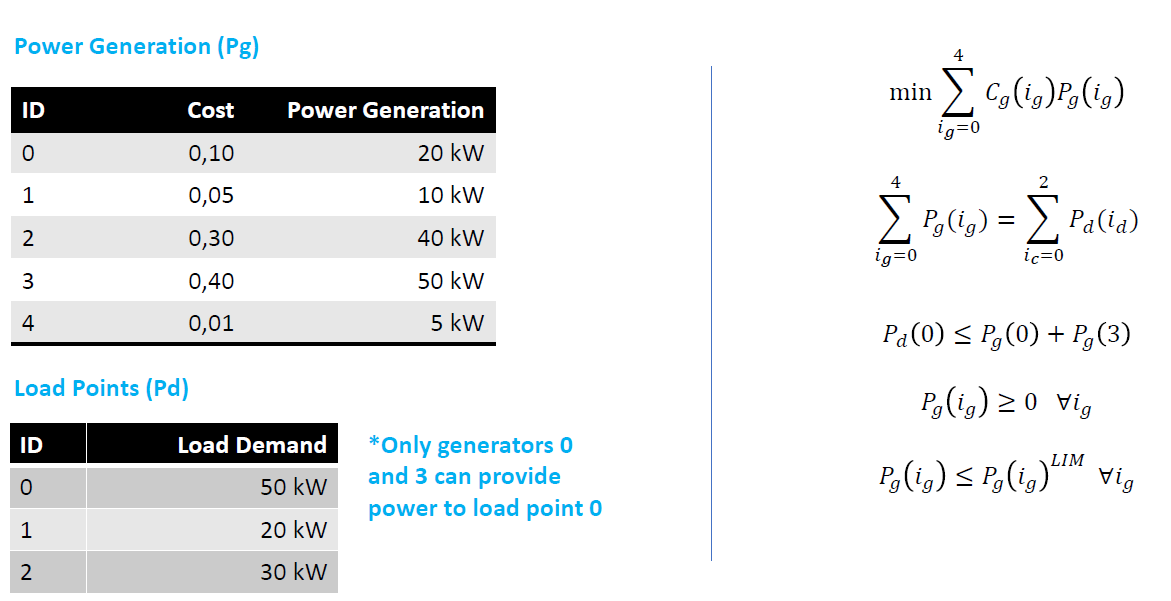

In [9]:
import pyomo.environ as pyo
from pyomo.environ import *
from pyomo.opt import SolverFactory
import pandas as pd

#inputs
dataGen = pd.read_excel('inputs.xlsx', sheet_name='gen')
dataLoad = pd.read_excel('inputs.xlsx', sheet_name='load')
Ng = len(dataGen)

#model
model = pyo.ConcreteModel()

model.Pg = pyo.Var(range(Ng), bounds=(0,None))
Pg = model.Pg

#constraints
pg_sum = sum([Pg[g] for g in dataGen.id])
model.balance = pyo.Constraint(expr = pg_sum == sum(dataLoad.value))

model.cond = pyo.Constraint(expr = Pg[0]+Pg[3] >= dataLoad.value[0])

model.limits = pyo.ConstraintList()
for g in dataGen.id:
    model.limits.add(expr = Pg[g] <= dataGen.limit[g])
    
#objFun
cost_sum = sum([Pg[g]*dataGen.cost[g] for g in dataGen.id])
model.obj = pyo.Objective(expr = cost_sum)

opt = SolverFactory('gurobi')
results = opt.solve(model)

dataGen['Pg'] = [pyo.value(Pg[g]) for g in dataGen.id]
model.pprint()
print('\n---------------------------------------------------------------------')
print(dataGen)

1 Var Declarations
    Pg : Size=5, Index={0, 1, 2, 3, 4}
        Key : Lower : Value : Upper : Fixed : Stale : Domain
          0 :     0 :  20.0 :  None : False : False :  Reals
          1 :     0 :  10.0 :  None : False : False :  Reals
          2 :     0 :  35.0 :  None : False : False :  Reals
          3 :     0 :  30.0 :  None : False : False :  Reals
          4 :     0 :   5.0 :  None : False : False :  Reals

1 Objective Declarations
    obj : Size=1, Index=None, Active=True
        Key  : Active : Sense    : Expression
        None :   True : minimize : 0.1*Pg[0] + 0.05*Pg[1] + 0.3*Pg[2] + 0.4*Pg[3] + 0.01*Pg[4]

3 Constraint Declarations
    balance : Size=1, Index=None, Active=True
        Key  : Lower : Body                                  : Upper : Active
        None : 100.0 : Pg[0] + Pg[1] + Pg[2] + Pg[3] + Pg[4] : 100.0 :   True
    cond : Size=1, Index=None, Active=True
        Key  : Lower : Body          : Upper : Active
        None :  50.0 : Pg[0] + Pg[3] :  +